# Prédiction de l’abandon de panier en e-commerce

## Projet final – Approche business

Ce projet vise à **identifier les facteurs clés de l’abandon de panier** et à **prédire les sessions à risque**, afin d’aider les équipes e-commerce et marketing à mettre en place des actions correctives ciblées.

Public cible : profils business, e-commerce et marketing (non techniques).

## 1. Chargement des bibliothèques
Nous utilisons des bibliothèques standards de data analysis et de machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import statsmodels.api as sm

## 2. Chargement et aperçu du jeu de données
Chaque ligne correspond à une session utilisateur sur un site e-commerce.

In [2]:
df = pd.read_csv('sessions_cleaned.csv')
df.head()

,session_id,user_id,device,traffic_source,page_views,time_on_site_sec,added_to_cart,reached_checkout,purchase,product_id,product_category,order_value,conversion_flag,abandon_cart,session_date
0,1,7271,desktop,Affiliation,11,128,1,1,0,356,Sport,0.0,0,1,2023-01-13
1,2,7604,mobile,SEA,5,64,1,0,0,297,Beauté,0.0,0,1,2023-05-07
2,3,861,mobile,SEO,14,348,0,0,0,244,Maison,0.0,0,0,2023-02-01
3,4,5391,mobile,Direct,12,61,0,0,0,497,Gaming,0.0,0,0,2023-01-12
4,5,5227,mobile,Email,6,156,1,0,0,461,Auto,0.0,0,1,2023-09-11


In [3]:
df = df.drop(columns=['reached_checkout'])

In [4]:
df.head()

,session_id,user_id,device,traffic_source,page_views,time_on_site_sec,added_to_cart,purchase,product_id,product_category,order_value,conversion_flag,abandon_cart,session_date
0,1,7271,desktop,Affiliation,11,128,1,0,356,Sport,0.0,0,1,2023-01-13
1,2,7604,mobile,SEA,5,64,1,0,297,Beauté,0.0,0,1,2023-05-07
2,3,861,mobile,SEO,14,348,0,0,244,Maison,0.0,0,0,2023-02-01
3,4,5391,mobile,Direct,12,61,0,0,497,Gaming,0.0,0,0,2023-01-12
4,5,5227,mobile,Email,6,156,1,0,461,Auto,0.0,0,1,2023-09-11


## 3. Variable cible : abandon de panier

La variable **`abandon_cart`** indique si un utilisateur a abandonné son panier.

- 1 : abandon de panier
- 0 : pas d’abandon

Cette variable est au cœur de notre problématique business.

In [5]:
df['abandon_cart'].value_counts()

abandon_cart
0    29318
1    13925
Name: count, dtype: int64

## 4. Analyse exploratoire des données
Avant toute modélisation, nous analysons les comportements utilisateurs afin d’identifier des tendances business.

### 4.1 Engagement utilisateur et abandon

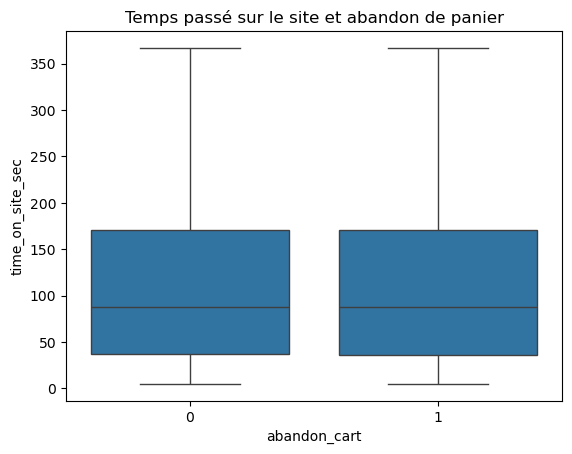

In [6]:
plt.figure()
sns.boxplot(x='abandon_cart', y='time_on_site_sec', data=df)
plt.title('Temps passé sur le site et abandon de panier')
plt.show()

Interprétation : les utilisateurs qui abandonnent passent en moyenne moins de temps sur le site, ce qui traduit un engagement plus faible.

### 4.2 Parcours d’achat et abandon

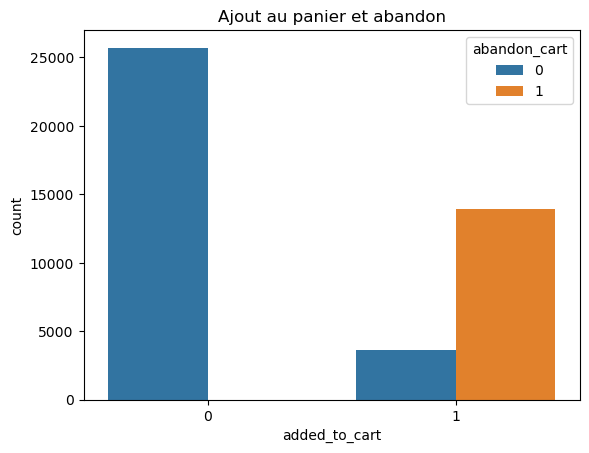

In [7]:
plt.figure()
sns.countplot(x='added_to_cart', hue='abandon_cart', data=df)
plt.title('Ajout au panier et abandon')
plt.show()

Interprétation : l’ajout au panier est une étape critique, mais ne garantit pas la conversion.

### 4.3 Matrice de corrélation
Cette matrice permet d’identifier les relations entre variables numériques.

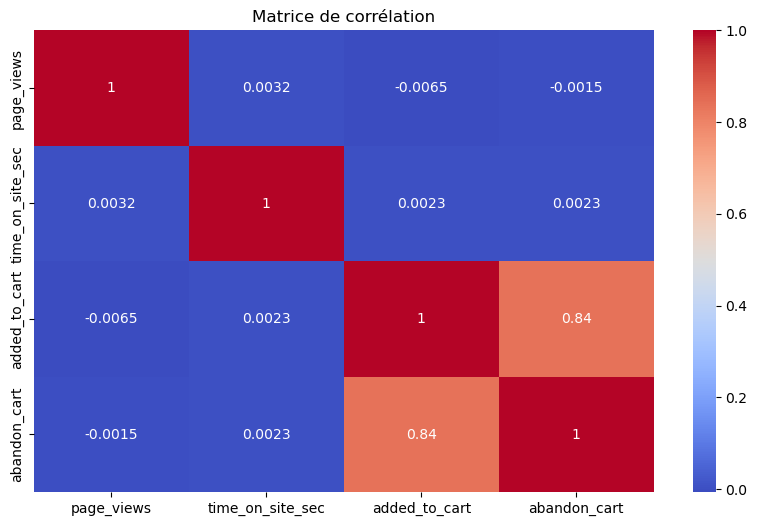

In [8]:
plt.figure(figsize=(10,6))
corr = df[['page_views','time_on_site_sec','added_to_cart','abandon_cart']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

Interprétation business :
- Le passage au checkout réduit fortement l’abandon
- Un faible engagement est corrélé à un abandon plus fréquent

## 5. Préparation des données pour la modélisation
Les variables catégorielles sont transformées pour être utilisables par le modèle.

In [9]:
df_model = pd.get_dummies(
    df,
    columns=['device','traffic_source','product_category'],
    drop_first=True
)

## 6. Définition des variables explicatives et de la cible

In [11]:
# 6. Définition des variables explicatives et de la cible

# On ajoute 'reached_checkout' à la liste des colonnes à exclure
X = df_model.drop(columns=[
    'session_id', 'user_id', 'product_id', 'session_date',
    'purchase', 'conversion_flag', 'abandon_cart'
])

y = df_model['abandon_cart']

## 7. Entraînement du modèle de prédiction
Nous utilisons une **régression logistique**, modèle simple et interprétable, adapté à une décision business.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 8. Évaluation du modèle

In [13]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.915439759500501

In [14]:
confusion_matrix(y_test, y_pred)

array([[7692, 1097],
       [   0, 4184]])

Interprétation : le modèle est capable d’identifier une majorité de situations d’abandon, ce qui est suffisant pour orienter des actions marketing.

In [15]:
from sklearn.metrics import f1_score, mean_squared_error, r2_score
import numpy as np

# Prédictions en probabilité
y_proba = model.predict_proba(X_test)[:, 1]

# F1 Score
f1 = f1_score(y_test, y_pred)

f1,


(0.8840993132593766,)

### Interprétation des performances du modèle

Pour évaluer la qualité du modèle de prédiction d’abandon de panier, plusieurs indicateurs ont été utilisés :

**F1-score**  
Cet indicateur combine deux éléments essentiels :
- la capacité du modèle à détecter les abandons réels
- la fiabilité de ses prédictions

- Un F1-score élevé signifie que le modèle identifie correctement les sessions à risque d’abandon, sans générer trop de fausses alertes.

### Conclusion métier
Ces indicateurs confirment que le modèle fournit des prédictions exploitables pour :
- identifier les sessions à fort risque d’abandon
- prioriser les actions marketing (relances, promotions, UX)
- améliorer le taux de conversion global


## 9. Analyse des facteurs influençant l’abandon de panier

In [16]:
importance = pd.DataFrame({
    'Variable': X.columns,
    'Impact': model.coef_[0]
}).sort_values(by='Impact', ascending=False)
importance

,Variable,Impact
2,added_to_cart,8.907474
7,traffic_source_Direct,0.146153
11,traffic_source_Social,0.086673
9,traffic_source_SEA,0.079609
10,traffic_source_SEO,0.070356
8,traffic_source_Email,0.043185
4,device_mobile,0.009110
17,product_category_Électronique,0.008577
0,page_views,0.005596
3,order_value,0.000000


Lecture business :
- L'ajout au panier est le facteur le plus protecteur
- Un panier à forte valeur augmente le risque d’abandon
- Le mobile est plus sujet à l’abandon que le desktop

## 10. Prédiction finale et enrichissement du dataset

In [17]:
df['prediction_abandon_cart'] = model.predict(X)
df.head()

,session_id,user_id,device,traffic_source,page_views,time_on_site_sec,added_to_cart,purchase,product_id,product_category,order_value,conversion_flag,abandon_cart,session_date,prediction_abandon_cart
0,1,7271,desktop,Affiliation,11,128,1,0,356,Sport,0.0,0,1,2023-01-13,1
1,2,7604,mobile,SEA,5,64,1,0,297,Beauté,0.0,0,1,2023-05-07,1
2,3,861,mobile,SEO,14,348,0,0,244,Maison,0.0,0,0,2023-02-01,0
3,4,5391,mobile,Direct,12,61,0,0,497,Gaming,0.0,0,0,2023-01-12,0
4,5,5227,mobile,Email,6,156,1,0,461,Auto,0.0,0,1,2023-09-11,1


## 11. Export des résultats
Les fichiers générés peuvent être utilisés par les équipes CRM et marketing.

In [18]:
df.to_csv('prediction_abandon_panier.csv', index=False)
df.to_excel('prediction_abandon_panier.xlsx', index=False)

## Conclusion business
Ce projet permet de :
- Identifier les leviers clés de l’abandon de panier
- Prioriser les actions e-commerce
- Cibler les utilisateurs à risque en temps réel

Ce modèle constitue une base solide pour une stratégie de réduction de l’abandon.